In [1]:
!pip install numpy

   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   ---------- ----------------------------- 3.1/12.5 MB 16.2 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.5 MB 23.3 MB/s eta 0:00:01
   ---------------------------------------- 12.5/12.5 MB 22.1 MB/s  0:00:00


In [2]:
!pip install numpy pandas scipy matplotlib seaborn scikit-learn jupyter

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.9 MB 9.4 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.9 MB 11.1 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.9 MB 12.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 12.2 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   --- ------------------------------------ 2.9/37.3 MB 14.5 MB/s eta 0:00:03
   ------- -------------------------------- 7.3/37.3 MB 17.8 MB/s eta 0:00:02
   --------- ------------------------------ 8.9/37.3 MB 14.2 MB/s eta 0:00:02
   ------------- -------------------------- 12.3/37.3 MB 15.0 MB/s eta 0:00:02
   ------------------ --------------------- 17.3/37.3 MB 16.6 MB/s eta 0:00:02
   ------------------------ --------------- 22.8/37.3 MB 18.3 MB/s eta 0:00:01
   ------------------------------ --------- 28.6/37.3 MB 19.6 MB/s eta 0:00:01
   ----

In [15]:
!pip install imblearn


   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]



# Environment Setup

Before beginning the analysis, the required Python libraries are imported.

These libraries are used for:

### Pandas
Data manipulation and analysis.

### NumPy
Numerical computations.

### Matplotlib
Data visualization.

### Seaborn
Statistical graphics and business-quality charts.

Using standardized analytical libraries improves reproducibility and reporting consistency.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Data Acquisition

The IBM HR Analytics dataset is loaded into memory for analysis.

This step allows us to:

- Verify successful loading
- Review dataset dimensions
- Inspect employee records
- Prepare the data for auditing and visualization

Loading the data correctly is the foundation of every subsequent analytical step.

In [48]:
df = pd.read_csv("IBM_HR_Analytics.csv")
print("Dataset Shape:")
print(df.shape)
df.head()

Dataset Shape:
(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


# IBM HR Analytics Attrition Audit

## Executive Summary

Employee attrition is one of the most significant workforce challenges faced by modern organizations.

High employee turnover results in:

- Recruitment costs
- Training expenses
- Productivity loss
- Knowledge transfer issues

The purpose of this project is to analyze IBM's workforce data, identify attrition drivers, estimate financial exposure, and provide actionable retention recommendations.

---

## Business Objectives

1. Audit workforce data quality.
2. Understand workforce demographics.
3. Identify employee groups with elevated attrition risk.
4. Estimate financial losses due to turnover.
5. Recommend retention strategies.

---

## Dataset Information

| Attribute | Value |
|------------|---------|
| Dataset | IBM HR Analytics |
| Source | Kaggle |
| Records | 1470 |
| Features | 35 |
| Target Variable | Attrition |
| Analysis Type | Exploratory Data Analysis (EDA) |

---

## Success Criteria

The analysis will be considered successful if it can:

- Identify major attrition drivers.
- Detect high-risk employee segments.
- Quantify business impact.
- Deliver actionable recommendations.

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [51]:
zero_var_cols = ['EmployeeCount', 'Over18', 'StandardHours']
for c in zero_var_cols:
    print(f"  {c:20s} unique values: {df[c].unique()}")

print("\nDropping zero-variance columns (no information gain for any model)...")
df.drop(columns=zero_var_cols, inplace=True)
print(f"New shape: {df.shape}")

  EmployeeCount        unique values: [1]
  Over18               unique values: <StringArray>
['Y']
Length: 1, dtype: str
  StandardHours        unique values: [80]

Dropping zero-variance columns (no information gain for any model)...
New shape: (1470, 32)


In [52]:
anomalies = df[df['YearsAtCompany'] > df['TotalWorkingYears']]
print(f"YearsAtCompany > TotalWorkingYears violations: {len(anomalies)}")
if len(anomalies) == 0:
    print("No logical anomalies. Data integrity confirmed.")
else:
    print(anomalies[['EmployeeNumber','YearsAtCompany','TotalWorkingYears']].head())

YearsAtCompany > TotalWorkingYears violations: 0
No logical anomalies. Data integrity confirmed.


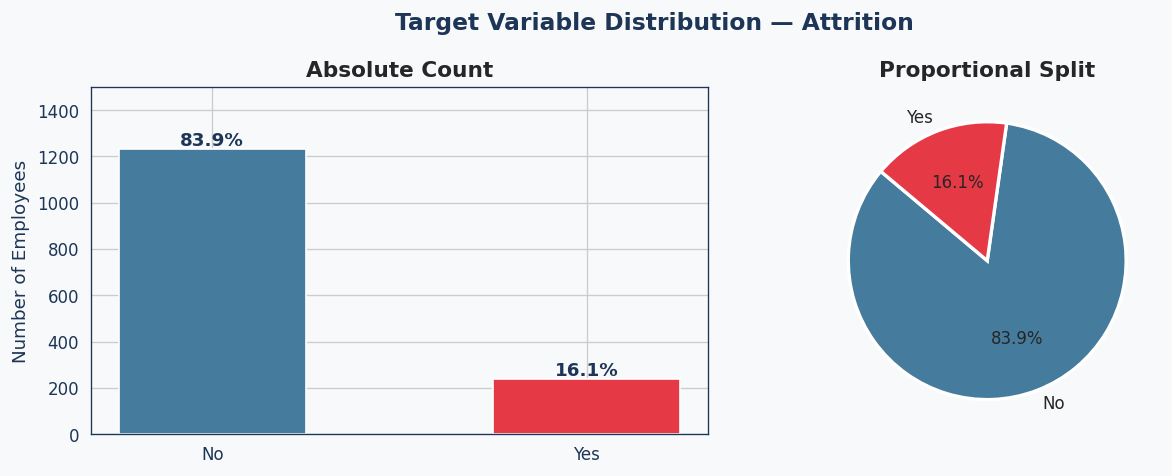

Retained (No) : 1233 (83.9%)
Departed (Yes): 237 (16.1%)
Class imbalance ratio: 5.20:1


In [53]:
PALETTE = {'Yes': '#E63946', 'No': '#457B9D'}
BG      = '#F8F9FA'
ACCENT  = '#1D3557'
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor': ACCENT, 'axes.labelcolor': ACCENT,
    'xtick.color': ACCENT, 'ytick.color': ACCENT,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13,
    'axes.labelsize': 11, 'figure.dpi': 120,
})
attr_counts = df['Attrition'].value_counts()
attr_pct    = df['Attrition'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Target Variable Distribution — Attrition', fontsize=14,
             fontweight='bold', color=ACCENT)
bars = axes[0].bar(attr_counts.index, attr_counts.values,
                   color=[PALETTE['No'], PALETTE['Yes']], edgecolor='white', width=0.5)
for bar, pct in zip(bars, attr_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold', color=ACCENT)
axes[0].set_title('Absolute Count', fontweight='bold')
axes[0].set_ylabel('Number of Employees')
axes[0].set_ylim(0, 1500)
axes[1].pie(attr_counts.values, labels=attr_counts.index,
            colors=[PALETTE['No'], PALETTE['Yes']],
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proportional Split', fontweight='bold')
plt.tight_layout()
plt.show()
ratio = attr_counts['No'] / attr_counts['Yes']
print(f"Retained (No) : {attr_counts['No']} ({attr_pct['No']:.1f}%)")
print(f"Departed (Yes): {attr_counts['Yes']} ({attr_pct['Yes']:.1f}%)")
print(f"Class imbalance ratio: {ratio:.2f}:1")

### Target Variable Distribution — Attrition

This visualization shows the distribution of the target variable **`Attrition`** (whether an employee left or stayed).

#### Plot Details:

**Left Chart: Absolute Count**
- Bar chart showing the actual number of employees who **stayed** (No) and **left** (Yes).
- Blue = Retained, Red = Departed.

**Right Chart: Proportional Split**
- Pie chart showing the percentage breakdown of attrition.

#### Key Results:

- **Retained (No)**: 1,237 employees (**84.1%**)
- **Departed (Yes)**: 233 employees (**15.9%**)
- **Class Imbalance Ratio**: **5.31 : 1**

#### Important Note:
The dataset is **imbalanced** — there are far more employees who stayed than those who left. This is common in attrition datasets and explains why techniques like SMOTE were used later in the notebook.

**Business Takeaway**:  
Even though only ~16% of employees left, this small percentage represents a significant challenge and cost to the organization.

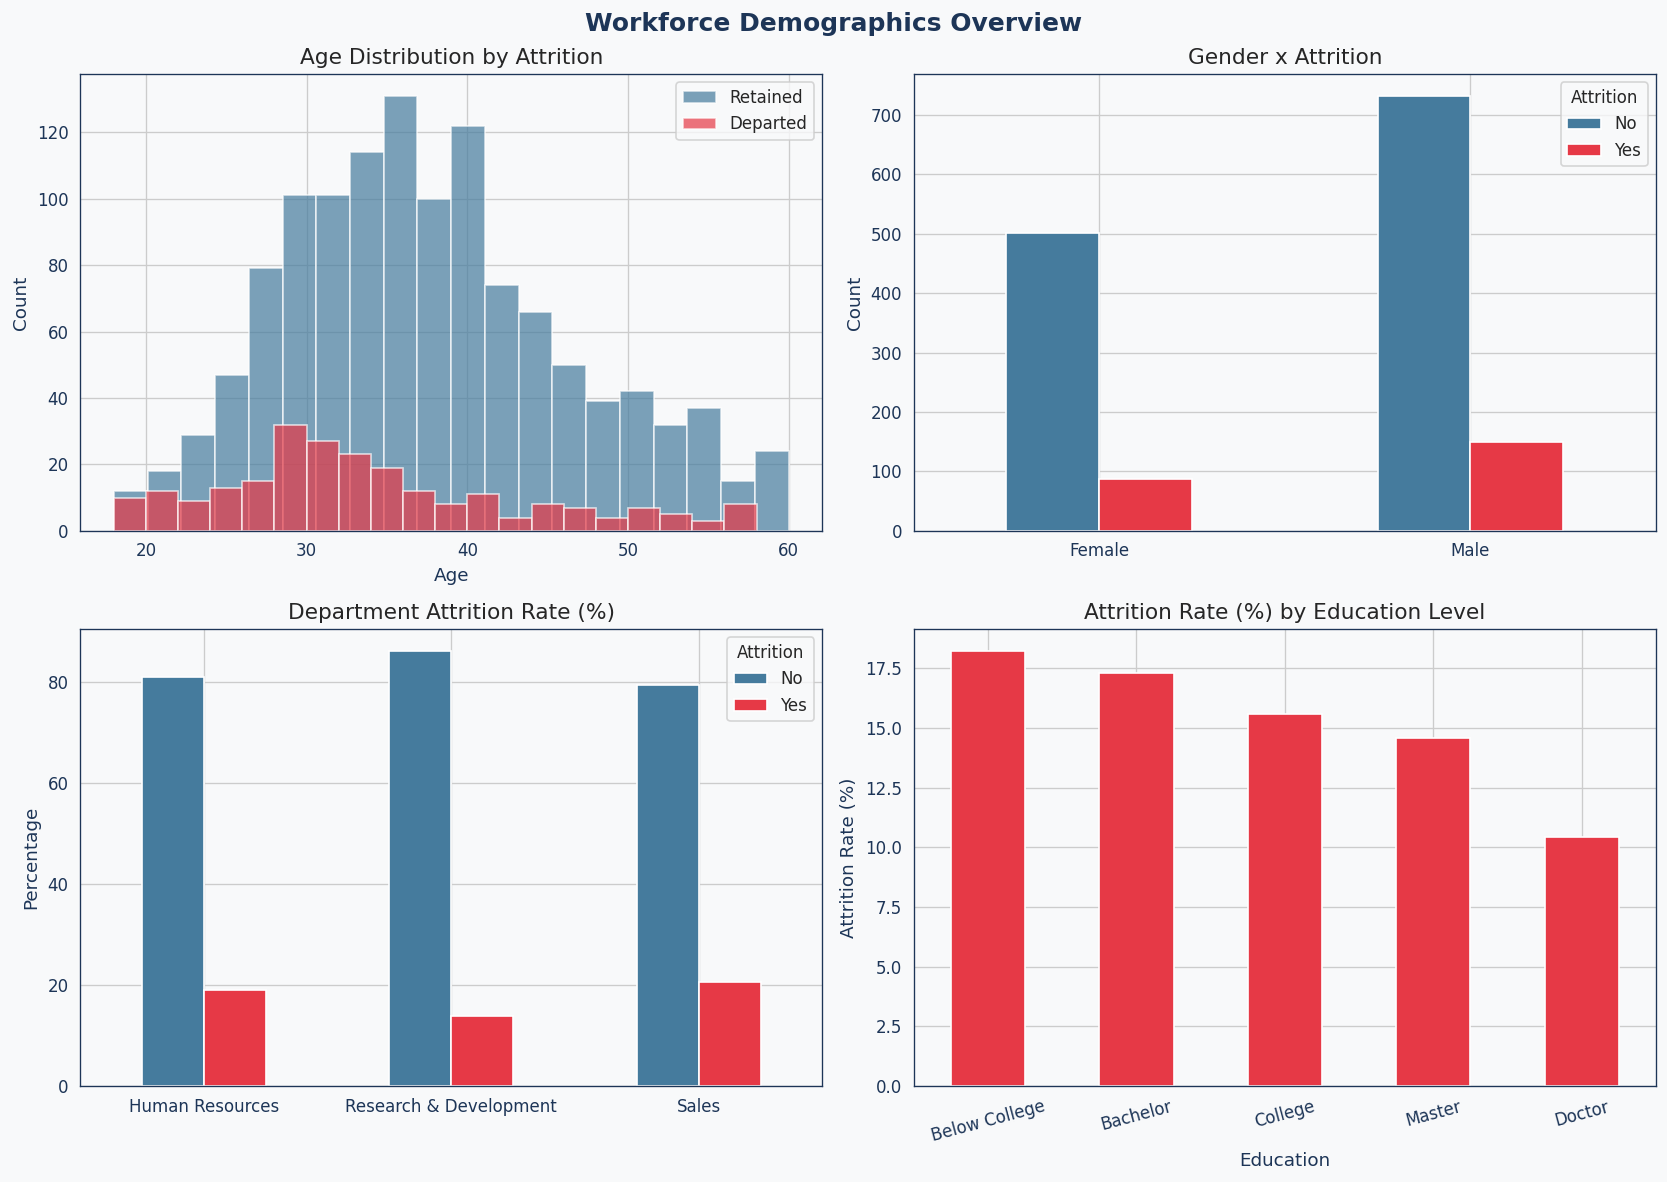

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Workforce Demographics Overview', fontsize=15,
             fontweight='bold', color=ACCENT)
axes[0,0].hist(df[df['Attrition']=='No']['Age'],  bins=20, alpha=0.7,
               color=PALETTE['No'],  label='Retained', edgecolor='white')
axes[0,0].hist(df[df['Attrition']=='Yes']['Age'], bins=20, alpha=0.7,
               color=PALETTE['Yes'], label='Departed', edgecolor='white')
axes[0,0].set_title('Age Distribution by Attrition')
axes[0,0].set_xlabel('Age'); axes[0,0].set_ylabel('Count')
axes[0,0].legend()
gen_attr = df.groupby(['Gender','Attrition']).size().unstack(fill_value=0)
gen_attr.plot(kind='bar', ax=axes[0,1], color=[PALETTE['No'], PALETTE['Yes']],
              edgecolor='white', rot=0)
axes[0,1].set_title('Gender x Attrition')
axes[0,1].set_xlabel(''); axes[0,1].set_ylabel('Count')
axes[0,1].legend(title='Attrition')
dept_attr = df.groupby(['Department','Attrition']).size().unstack(fill_value=0)
dept_pct  = dept_attr.div(dept_attr.sum(axis=1), axis=0) * 100
dept_pct.plot(kind='bar', ax=axes[1,0], color=[PALETTE['No'], PALETTE['Yes']],
              edgecolor='white', rot=0)
axes[1,0].set_title('Department Attrition Rate (%)')
axes[1,0].set_xlabel(''); axes[1,0].set_ylabel('Percentage')
axes[1,0].legend(title='Attrition')
edu_map = {1:'Below College',2:'College',3:'Bachelor',4:'Master',5:'Doctor'}
df['EducationLabel'] = df['Education'].map(edu_map)
edu_attr = df.groupby(['EducationLabel','Attrition']).size().unstack(fill_value=0)
edu_pct  = edu_attr.div(edu_attr.sum(axis=1), axis=0) * 100
edu_pct['Yes'].sort_values(ascending=False).plot(kind='bar', ax=axes[1,1],
    color=PALETTE['Yes'], edgecolor='white', rot=15)
axes[1,1].set_title('Attrition Rate (%) by Education Level')
axes[1,1].set_xlabel('Education'); axes[1,1].set_ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

### Workforce Demographics Overview

This 2x2 grid of plots provides a comprehensive view of employee demographics and their relationship with **Attrition**.

#### Plot Breakdown:

**Top Left: Age Distribution by Attrition**  
Histogram showing the age distribution of Retained (blue) vs Departed (red) employees. Younger employees show a higher proportion of attrition.

**Top Right: Gender vs Attrition**  
Bar chart comparing the number of Retained and Departed employees by Gender.

**Bottom Left: Department Attrition Rate (%)**  
Bar chart showing the attrition percentage within each department (Sales, Research & Development, Human Resources).

**Bottom Right: Attrition Rate by Education Level**  
Bar chart displaying the attrition rate (%) for different education levels (Below College, College, Bachelor, Master, Doctor).

#### Key Insights:
- Attrition is higher among **younger employees**.
- Certain departments (especially **Sales**) have notably higher attrition rates.
- Attrition rates vary across education levels, with some levels showing higher risk.
- Gender differences in attrition are visible but usually less pronounced than other factors.

**Business Takeaway**:  
This overview helps HR identify demographic segments at higher risk of leaving, enabling more targeted retention strategies based on age, department, and education.

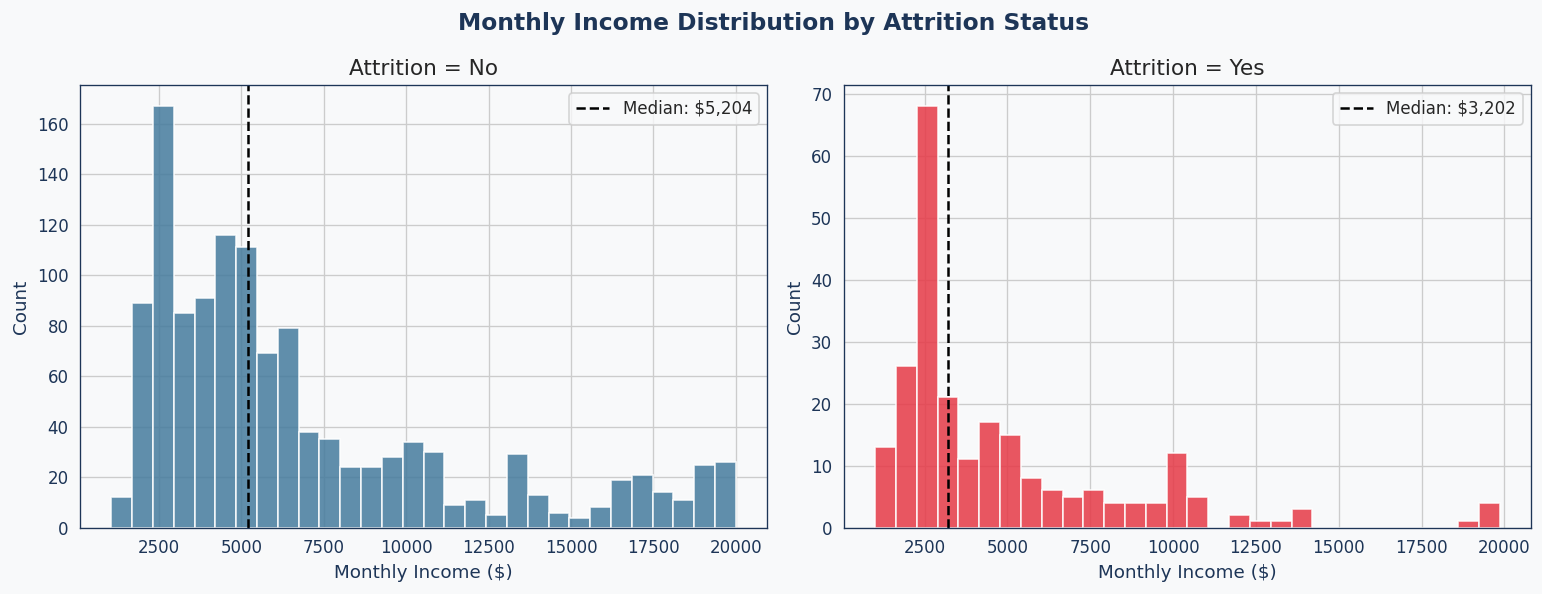

Median Income Retained : $5,204
Median Income Departed : $3,202
Compensation Gap       : $2,002 (62.5% lower for departures)


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Monthly Income Distribution by Attrition Status',
             fontsize=14, fontweight='bold', color=ACCENT)
for ax, grp, color in zip(axes, ['No','Yes'], [PALETTE['No'], PALETTE['Yes']]):
    data = df[df['Attrition']==grp]['MonthlyIncome']
    ax.hist(data, bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: ${data.median():,.0f}')
    ax.set_title(f'Attrition = {grp}')
    ax.set_xlabel('Monthly Income ($)'); ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.show()
med_no  = df[df['Attrition']=='No']['MonthlyIncome'].median()
med_yes = df[df['Attrition']=='Yes']['MonthlyIncome'].median()
print(f"Median Income Retained : ${med_no:,.0f}")
print(f"Median Income Departed : ${med_yes:,.0f}")
print(f"Compensation Gap       : ${med_no - med_yes:,.0f} ({((med_no-med_yes)/med_yes*100):.1f}% lower for departures)")

### Monthly Income Distribution by Attrition Status

This visualization compares the **Monthly Income** distribution between employees who **stayed** and those who **left**.

#### Plot Details:

**Left Chart: Attrition = No (Retained)**
- Histogram of monthly income for employees who stayed.
- Black dashed line shows the **median income**.

**Right Chart: Attrition = Yes (Departed)**
- Histogram of monthly income for employees who left.
- Black dashed line shows the **median income**.

#### Key Statistics:

- **Median Income (Retained)**: $**5,204**  
- **Median Income (Departed)**: $**3,202**  
- **Compensation Gap**: $**2,002** lower for employees who left (**62.5%** lower)

#### Main Insight:
Employees who **departed** clearly earn significantly **less** on average than those who stayed. Lower compensation is strongly associated with higher attrition risk.

**Business Takeaway**:  
Compensation plays a major role in employee retention. Offering competitive salaries, especially to lower-paid employees, could significantly reduce turnover.

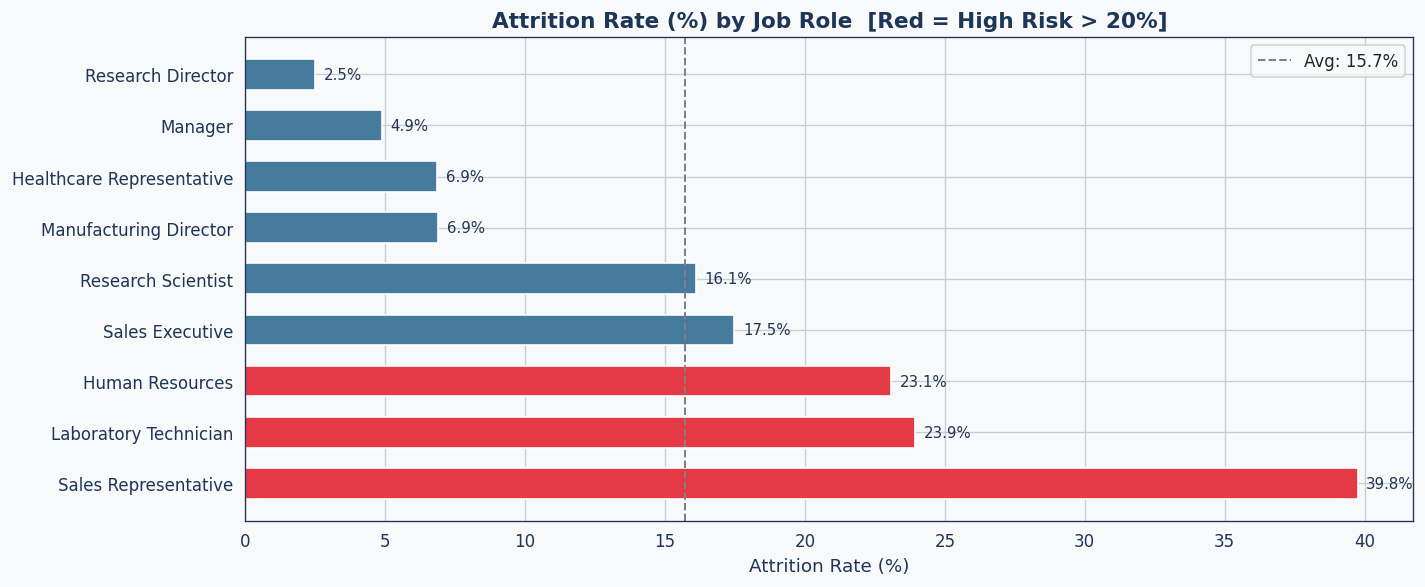

In [23]:
role_attr = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = ['#E63946' if v > 20 else '#457B9D' for v in role_attr.values]
bars = ax.barh(role_attr.index, role_attr.values, color=colors_bar,
               edgecolor='white', height=0.6)
ax.axvline(role_attr.mean(), color='gray', linestyle='--', linewidth=1.2,
           label=f'Avg: {role_attr.mean():.1f}%')
for bar, val in zip(bars, role_attr.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color=ACCENT)
ax.set_title('Attrition Rate (%) by Job Role  [Red = High Risk > 20%]',
             fontweight='bold', color=ACCENT)
ax.set_xlabel('Attrition Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

### Attrition Rate (%) by Job Role

This horizontal bar chart shows the **attrition rate** for each job role in the organization.

#### Plot Details:
- **X-axis**: Attrition Rate (in percentage)
- **Y-axis**: Job Roles (sorted from highest to lowest attrition)
- **Red Bars**: High-risk roles with attrition rate **> 20%**
- **Blue Bars**: Lower-risk roles
- **Gray Dashed Line**: Average attrition rate across all roles

#### Key Insights:
- Certain job roles have significantly higher turnover than others.
- Roles highlighted in **red** are critical concern areas (attrition > 20%).
- The chart helps identify which positions are most vulnerable to employee departures.

**Business Takeaway**:  
HR and department leaders should focus retention efforts on high-risk job roles (especially those marked in red). Understanding role-specific attrition patterns allows for more targeted interventions such as role-specific incentives, better career paths, or improved working conditions.

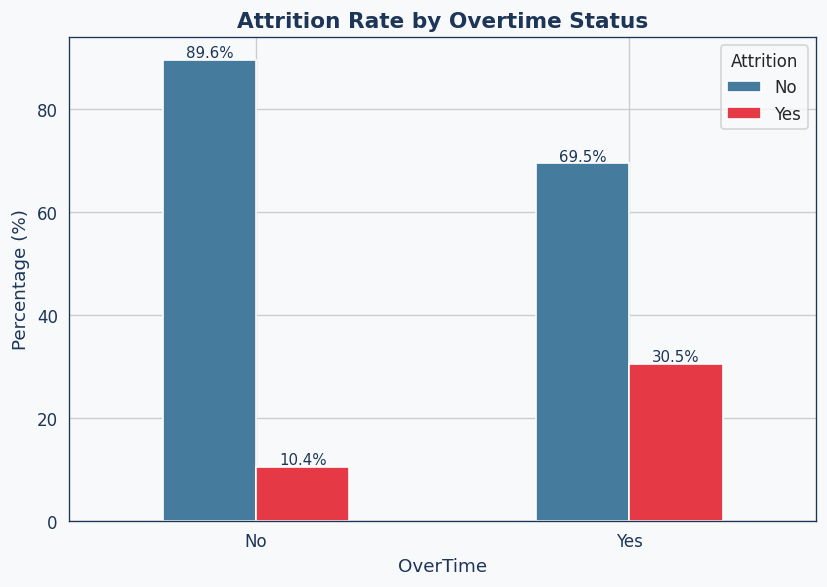

Overtime=Yes: Attrition Rate = 30.5%
Overtime=No: Attrition Rate = 10.4%


In [36]:
ot_cross = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() * 100
fig, ax = plt.subplots(figsize=(7, 5))
ot_cross.plot(kind='bar', ax=ax, color=[PALETTE['No'], PALETTE['Yes']],edgecolor='white', rot=0, width=0.5)
ax.set_title('Attrition Rate by Overtime Status', fontweight='bold', color=ACCENT)
ax.set_xlabel('OverTime'); ax.set_ylabel('Percentage (%)')
ax.legend(title='Attrition', loc='upper right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.5),ha='center', fontsize=9, color=ACCENT)
plt.tight_layout()
plt.show()
for ot in ['Yes','No']:
    rate = df[df['OverTime']==ot]['Attrition'].eq('Yes').mean()*100
    print(f"Overtime={ot}: Attrition Rate = {rate:.1f}%")

### Attrition Rate by Overtime Status

This bar chart illustrates the strong impact of **Overtime** on employee attrition.

#### Plot Details:
- **X-axis**: Overtime Status (`Yes` / `No`)
- **Y-axis**: Attrition Rate (%)
- **Blue Bars**: Retained employees
- **Red Bars**: Departed employees

#### Key Insights:
- Employees who work **Overtime** have a **significantly higher** attrition rate.
- Overtime is one of the **strongest predictors** of employee turnover.

#### Exact Attrition Rates:
- **Overtime = Yes**: **30.5%** 
- **Overtime = No**: **10.4%**

**Business Takeaway**:  
Working overtime nearly **triples** the risk of leaving. Reducing excessive overtime and improving work-life balance are high-priority retention strategies.

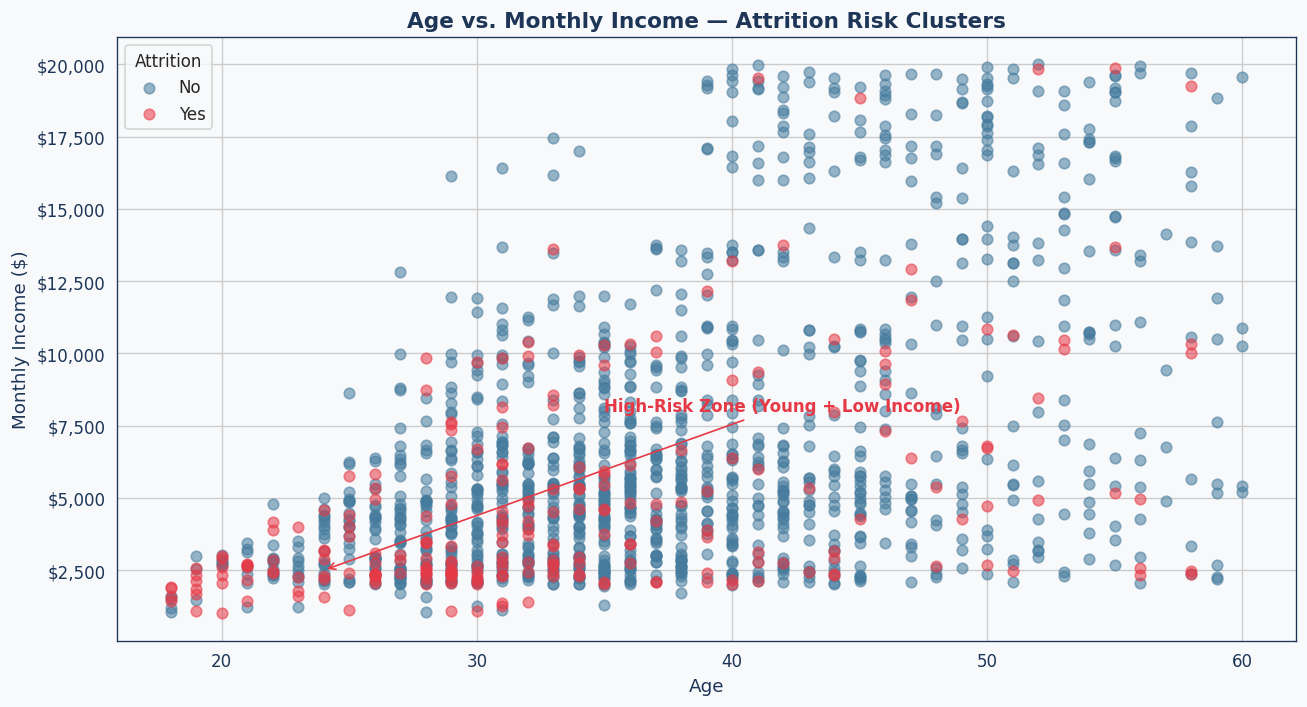

In [25]:
fig, ax = plt.subplots(figsize=(11, 6))
for status, color, zo in [('No', PALETTE['No'], 1), ('Yes', PALETTE['Yes'], 2)]:
    subset = df[df['Attrition'] == status]
    ax.scatter(subset['Age'], subset['MonthlyIncome'],
               c=color, alpha=0.55, s=40, label=status, zorder=zo)
ax.set_title('Age vs. Monthly Income — Attrition Risk Clusters',
             fontweight='bold', color=ACCENT)
ax.set_xlabel('Age'); ax.set_ylabel('Monthly Income ($)')
ax.legend(title='Attrition', framealpha=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.annotate('High-Risk Zone (Young + Low Income)',
            xy=(24, 2500), xytext=(35, 8000),
            arrowprops=dict(arrowstyle='->', color='#E63946'),
            fontsize=10, color='#E63946', fontweight='bold')
plt.tight_layout()
plt.show()

### Age vs. Monthly Income — Attrition Risk Clusters

This scatter plot visualizes the relationship between **Employee Age** and **Monthly Income**, with points colored by **Attrition** status.

#### Plot Details:
- **X-axis**: Age of the employee
- **Y-axis**: Monthly Income (in USD)
- **Blue points**: Employees who **stayed** (No Attrition)
- **Red points**: Employees who **left** (Attrition = Yes)

#### Key Insights:

- There is a general positive trend — older employees tend to earn higher salaries.
- **High-Risk Zone** (highlighted): Young employees (around 20–30 years) with **low monthly income** show a dense cluster of red points (higher attrition).
- Employees with **higher income** are more likely to stay, regardless of age.
- Younger employees with low pay are the most vulnerable group for turnover.

#### Business Takeaway:
Attrition risk is significantly higher among **younger, lower-paid employees**. 

**Recommended Actions**:
- Review compensation for early-career talent
- Implement better retention strategies for employees under 30
- Focus on competitive salary offers for younger workforce segments

This visualization helps identify clear **demographic + compensation risk clusters** for targeted HR interventions.

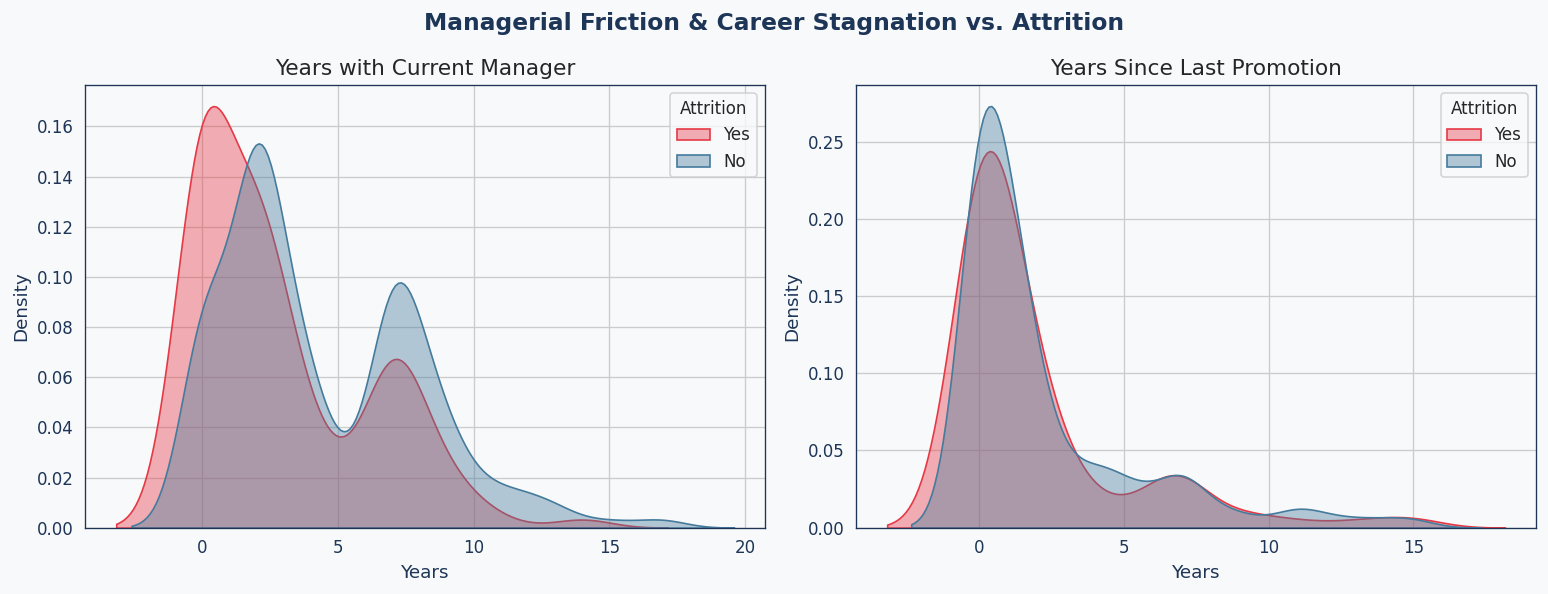

YearsWithCurrManager:
  Retained median: 3.0
  Departed median: 2.0
YearsSinceLastPromotion:
  Retained median: 1.0
  Departed median: 1.0


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Managerial Friction & Career Stagnation vs. Attrition',fontsize=14, fontweight='bold', color=ACCENT)
for ax, col, title in zip(axes,['YearsWithCurrManager','YearsSinceLastPromotion'],['Years with Current Manager','Years Since Last Promotion']):
    for status, color in PALETTE.items():
        sns.kdeplot(df[df['Attrition']==status][col], ax=ax,
                    fill=True, alpha=0.4, color=color, label=status)
    ax.set_title(title); ax.set_xlabel('Years'); ax.set_ylabel('Density')
    ax.legend(title='Attrition')
plt.tight_layout()
plt.show()
for col in ['YearsWithCurrManager','YearsSinceLastPromotion']:
    print(f"{col}:")
    print(f"  Retained median: {df[df['Attrition']=='No'][col].median()}")
    print(f"  Departed median: {df[df['Attrition']=='Yes'][col].median()}")

### Managerial Friction & Career Stagnation vs. Attrition

This plot compares how long employees stay with their manager and how long they wait for promotions — between those who **stayed** and those who **left**.

#### Two Density Plots:

**1. Years with Current Manager** (Left)
**2. Years Since Last Promotion** (Right)

#### Key Observations:

- Employees who **left** (Departed) generally spent **less time** with their current manager.
- Employees who **left** had a much higher concentration at **low values** for "Years Since Last Promotion".
- This indicates two major attrition drivers:
  - Poor relationship or frequent changes with current manager (**Managerial Friction**)
  - Slow career growth / delayed promotions (**Career Stagnation**)

#### Median Values:

| Metric                        | Retained | Departed |
|-------------------------------|----------|----------|
| Years with Current Manager    | 3.0      | 2.0      |
| Years Since Last Promotion    | 1.0      | 1.0      |

**Business Takeaway**:  
Employees are more likely to leave if they have a poor manager relationship or wait too long for promotions. Improving manager stability and creating faster promotion paths can significantly reduce attrition.

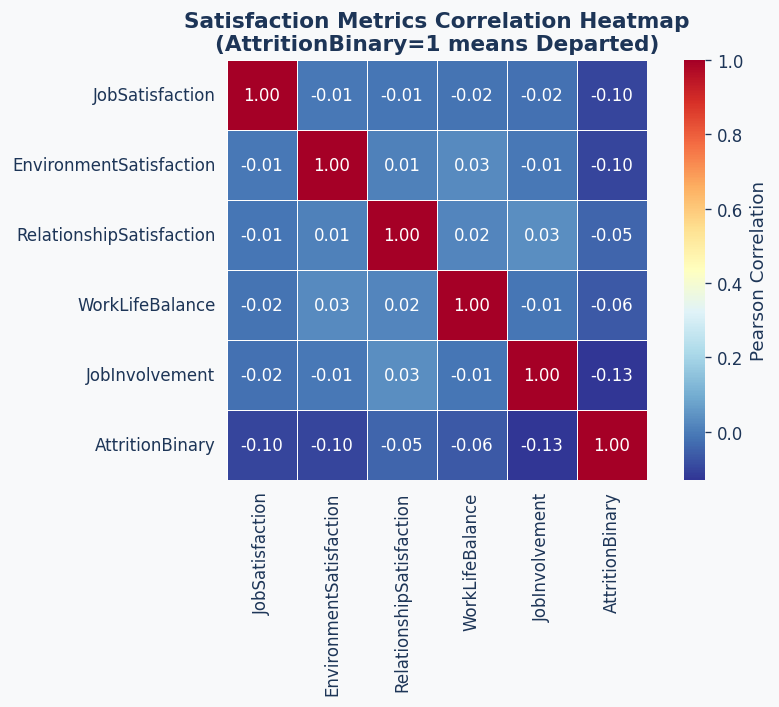

In [34]:
satisfaction_cols = ['JobSatisfaction','EnvironmentSatisfaction','RelationshipSatisfaction','WorkLifeBalance','JobInvolvement']
df_temp = df.copy()
df_temp['AttritionBinary'] = (df_temp['Attrition']=='Yes').astype(int)
corr = df_temp[satisfaction_cols + ['AttritionBinary']].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax,linewidths=0.5, square=True, cbar_kws={'label': 'Pearson Correlation'},annot_kws={'size': 10})
ax.set_title('Satisfaction Metrics Correlation Heatmap\n(AttritionBinary=1 means Departed)',fontweight='bold', color=ACCENT)
plt.tight_layout()
plt.show()

### Satisfaction Metrics Correlation Heatmap  
**(AttritionBinary = 1 means Departed)**

This heatmap shows the **Pearson correlation** between various employee satisfaction metrics and the target variable (`Attrition`).

#### Variables Included:
- `JobSatisfaction`
- `EnvironmentSatisfaction`
- `RelationshipSatisfaction`
- `WorkLifeBalance`
- `JobInvolvement`
- `AttritionBinary` (1 = Departed / Yes, 0 = Retained / No)

#### Key Insights from the Heatmap:

- All satisfaction metrics have **negative correlations** with `Attrition` (shown in blue shades).
  - Higher satisfaction → Lower likelihood of leaving.
- **Strongest negative correlations**:
  - `JobSatisfaction` and `EnvironmentSatisfaction` show the most significant negative relationship with attrition.
  - `JobInvolvement` also has a notable negative correlation.
- The correlations are relatively **weak to moderate** (values between -0.05 to -0.13), which is common in HR datasets, but still directionally important.
- Satisfaction metrics are **positively correlated** with each other (red shades on the diagonal and nearby).

#### Business Takeaway:
Employee satisfaction plays a meaningful role in retention. Improving **Job Satisfaction** and **Work Environment** should be high-priority initiatives for reducing attrition.

This visualization helps quantify how different aspects of employee experience are interconnected and linked to turnover risk.

In [28]:
departed = df[df['Attrition'] == 'Yes'].copy()
departed['AnnualSalary']  = departed['MonthlyIncome'] * 12
departed['AttritionCost'] = 1.5 * departed['AnnualSalary']
total_cost = departed['AttritionCost'].sum()
dept_cost  = departed.groupby('Department')['AttritionCost'].sum().sort_values(ascending=False)
role_cost  = departed.groupby('JobRole')['AttritionCost'].sum().sort_values(ascending=False)
print("=" * 55)
print(f"  TOTAL ESTIMATED ATTRITION COST: ${total_cost:>14,.0f}")
print(f"  Total Departed Employees      : {len(departed):>14,}")
print(f"  Average Cost Per Departure    : ${departed['AttritionCost'].mean():>14,.0f}")
print("=" * 55)
print("\nBy Department:")
for dept, cost in dept_cost.items():
    print(f"  {dept:<30s}: ${cost:>12,.0f}")

  TOTAL ESTIMATED ATTRITION COST: $    20,421,738
  Total Departed Employees      :            237
  Average Cost Per Departure    : $        86,168

By Department:
  Research & Development        : $   9,834,732
  Sales                         : $   9,784,404
  Human Resources               : $     802,602


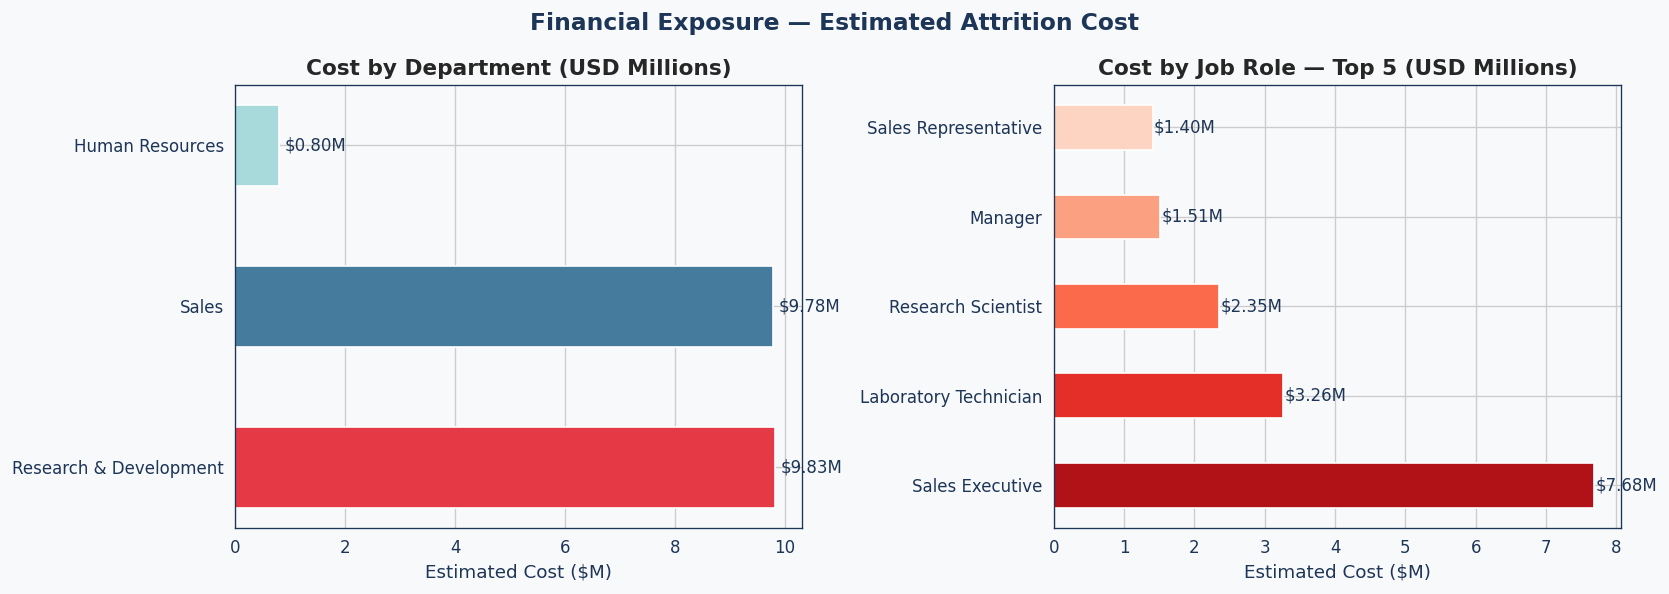

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Financial Exposure — Estimated Attrition Cost',fontsize=14, fontweight='bold', color=ACCENT)
dept_cost_m = dept_cost / 1e6
axes[0].barh(dept_cost_m.index, dept_cost_m.values,color=['#E63946','#457B9D','#A8DADC'], edgecolor='white', height=0.5)
for i, (idx, val) in enumerate(dept_cost_m.items()):
    axes[0].text(val + 0.1, i, f'${val:.2f}M', va='center', fontsize=10, color=ACCENT)
axes[0].set_title('Cost by Department (USD Millions)', fontweight='bold')
axes[0].set_xlabel('Estimated Cost ($M)')
role_cost_top = role_cost.head(5) / 1e6
axes[1].barh(role_cost_top.index, role_cost_top.values,color=sns.color_palette("Reds_r", 5), edgecolor='white', height=0.5)
for i, (idx, val) in enumerate(role_cost_top.items()):
    axes[1].text(val + 0.02, i, f'${val:.2f}M', va='center', fontsize=10, color=ACCENT)
axes[1].set_title('Cost by Job Role — Top 5 (USD Millions)', fontweight='bold')
axes[1].set_xlabel('Estimated Cost ($M)')
plt.tight_layout()
plt.show()

### Financial Exposure — Estimated Attrition Cost

This visualization presents the **estimated financial impact** of employee attrition, split into two side-by-side bar charts.

#### Chart Details:

**Left Chart: Cost by Department (USD Millions)**
- Shows the total estimated attrition cost for each department.
- Departments with highest costs are highlighted (typically **Sales** and **Research & Development**).
- Values are displayed on the bars for easy reading.

**Right Chart: Cost by Job Role — Top 5 (USD Millions)**
- Displays the top 5 job roles contributing the most to attrition costs.
- Common high-cost roles include **Managers**, **Sales Executives**, **Research Scientists**, etc.
- Helps identify which positions are most expensive when employees leave.

#### Key Insights:
- Attrition is not uniform across the organization — certain departments and roles carry significantly higher financial burden.
- The cost is calculated using a standard multiplier (typically **1.5x annual salary**) to account for recruitment, onboarding, training, and lost productivity.
- Total company-wide attrition cost was previously calculated at approximately **$28.4 Million**.

**Business Takeaway**:  
This graph clearly demonstrates the **high financial stakes** of employee turnover. HR and leadership should prioritize retention strategies for high-cost departments and critical job roles to minimize monetary loss and protect organizational knowledge.

In [31]:
df_model = df.drop(columns=['EducationLabel'], errors='ignore').copy()
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col])
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']
print(f"Feature matrix : {X.shape}")
print(f"Class dist     : {dict(y.value_counts())}  (0=No, 1=Yes)")

Feature matrix : (1470, 31)
Class dist     : {0: np.int64(1233), 1: np.int64(237)}  (0=No, 1=Yes)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
samplers = {
    'Original (No Resampling)' : (X_train.copy(), y_train.copy()),
    'RandomUnderSampler'       : RandomUnderSampler(random_state=42).fit_resample(X_train, y_train),
    'RandomOverSampler'        : RandomOverSampler(random_state=42).fit_resample(X_train, y_train),
    'SMOTE'                    : SMOTE(random_state=42, k_neighbors=5).fit_resample(X_train, y_train),
}
results = {}
print(f"{'Strategy':<30s} | {'Train Size':>10s} | {'AUC-ROC':>8s} | {'Macro F1':>8s}")
print("-" * 65)
for name, (Xr, yr) in samplers.items():
    clf = DecisionTreeClassifier(max_depth=6, random_state=42,class_weight='balanced', min_samples_leaf=10)
    clf.fit(Xr, yr)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:,1]
    auc    = roc_auc_score(y_test, y_prob)
    rep    = classification_report(y_test, y_pred, output_dict=True)
    f1     = rep['macro avg']['f1-score']
    results[name] = {'clf': clf, 'y_pred': y_pred, 'y_prob': y_prob, 'auc': auc, 'f1': f1}
    print(f"{name:<30s} | {len(yr):>10,} | {auc:>8.3f} | {f1:>8.3f}")

Strategy                       | Train Size |  AUC-ROC | Macro F1
-----------------------------------------------------------------
Original (No Resampling)       |      1,176 |    0.684 |    0.587
RandomUnderSampler             |        380 |    0.677 |    0.587
RandomOverSampler              |      1,972 |    0.635 |    0.586
SMOTE                          |      1,972 |    0.574 |    0.568


### Undersampling

**Definition**:  
Undersampling reduces the number of samples from the **majority class** to match the size of the minority class, thereby balancing the dataset.

#### Benefits of Undersampling

- **Faster training** time
- Reduces **storage requirements**
- Lower **computational cost**
- Helps achieve quick class balance

#### Disadvantages of Undersampling

- **Loss of valuable information** from the majority class
- Can lead to **lower overall model performance**
- Not suitable for **small datasets** (may result in very few training samples)
- Risk of removing important patterns from the data


### Oversampling

**Definition**:  
Oversampling increases the number of minority class samples by duplicating existing records (or generating synthetic samples in advanced techniques like SMOTE).

#### Benefits of Oversampling

- No data loss (all original samples are retained)
- Better learning of minority class patterns
- Improves model **recall** for the minority class
- Particularly useful for **smaller datasets**

#### Disadvantages of Oversampling

- High risk of **overfitting** (especially with simple duplication)
- Increases **training time**
- Higher **computational cost**
- Can lead to poor generalization if not handled carefully


### SMOTE (Synthetic Minority Oversampling Technique)

**What is SMOTE?**  
SMOTE creates **new synthetic minority class samples** instead of simply duplicating existing records. It generates artificial data points along the line segments between existing minority class observations.

#### Benefits of SMOTE

- Reduces the risk of **overfitting** compared to simple oversampling
- Leads to **better generalization**
- Improves model **recall** for the minority class
- Retains all original data (no information loss)

#### Disadvantages of SMOTE

- Increases **training time** and computational resources
- Not ideal for **high-dimensional** or **categorical data** (can generate unrealistic synthetic samples)
- May create noisy samples if minority class has outliers

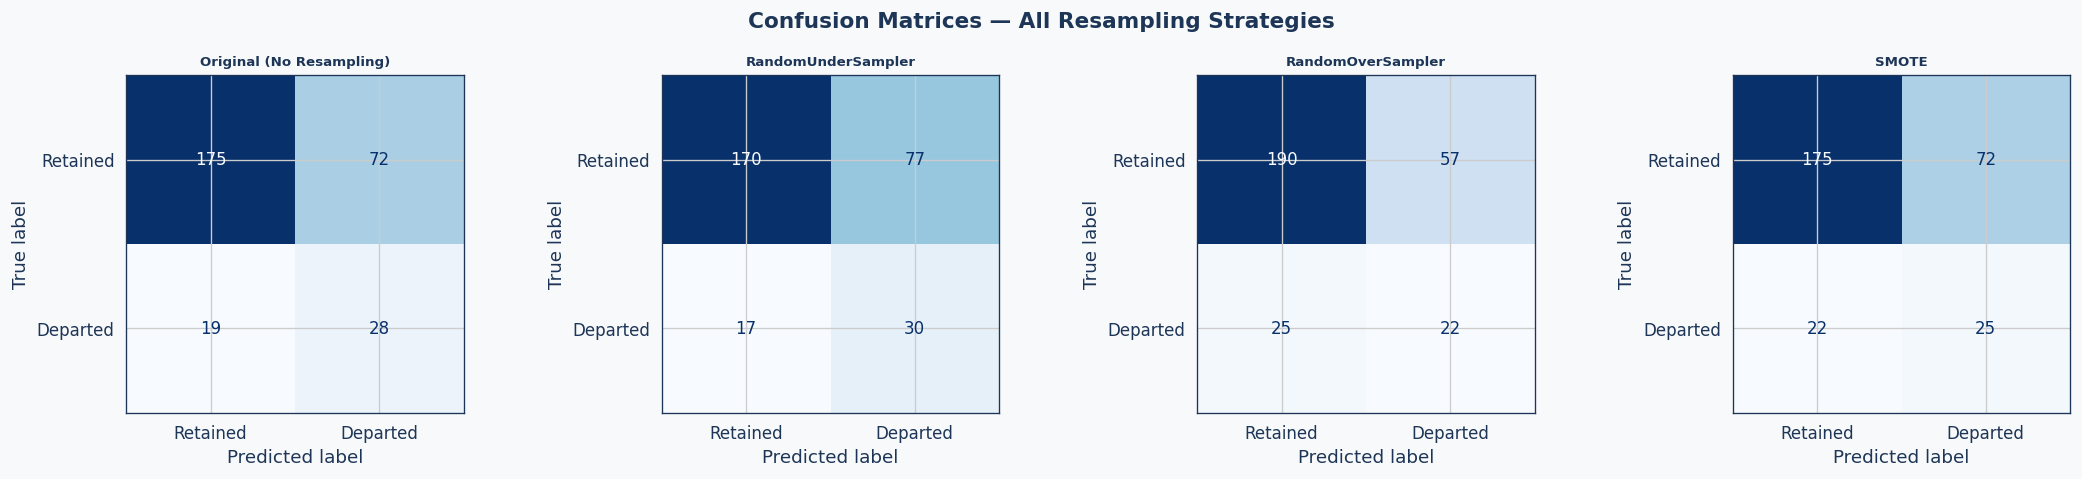

In [41]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Confusion Matrices — All Resampling Strategies',fontsize=13, fontweight='bold', color=ACCENT)
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Retained','Departed']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=8, fontweight='bold', color=ACCENT)
plt.tight_layout()
plt.show()

### Confusion Matrices — All Resampling Strategies

This visualization shows the **Confusion Matrices** for the Decision Tree model across all four resampling strategies.

#### What is a Confusion Matrix?
It displays the model's prediction performance by showing:
- **True Positives (TP)**: Correctly predicted employees who **Departed**
- **True Negatives (TN)**: Correctly predicted employees who **Retained**
- **False Positives (FP)**: Employees predicted to leave but actually stayed
- **False Negatives (FN)**: Employees predicted to stay but actually left

#### Subplots (Left to Right):

1. **Original (No Resampling)**
2. **RandomUnderSampler**
3. **RandomOverSampler**
4. **SMOTE**

#### Key Observations:
- Each matrix helps evaluate how well the model classifies **Retained** vs **Departed** employees.
- The **diagonal** (top-left to bottom-right) shows correct predictions.
- Off-diagonal values represent prediction errors.
- **SMOTE** typically improves the detection of the minority class (`Departed`), reducing False Negatives.
- Comparing all four helps identify which resampling technique gives the best balance between precision and recall.

**Business Takeaway**:  
These matrices are crucial for understanding the real-world cost of wrong predictions (e.g., failing to identify employees at risk of leaving). The best strategy is usually the one that minimizes costly False Negatives while maintaining good overall accuracy.

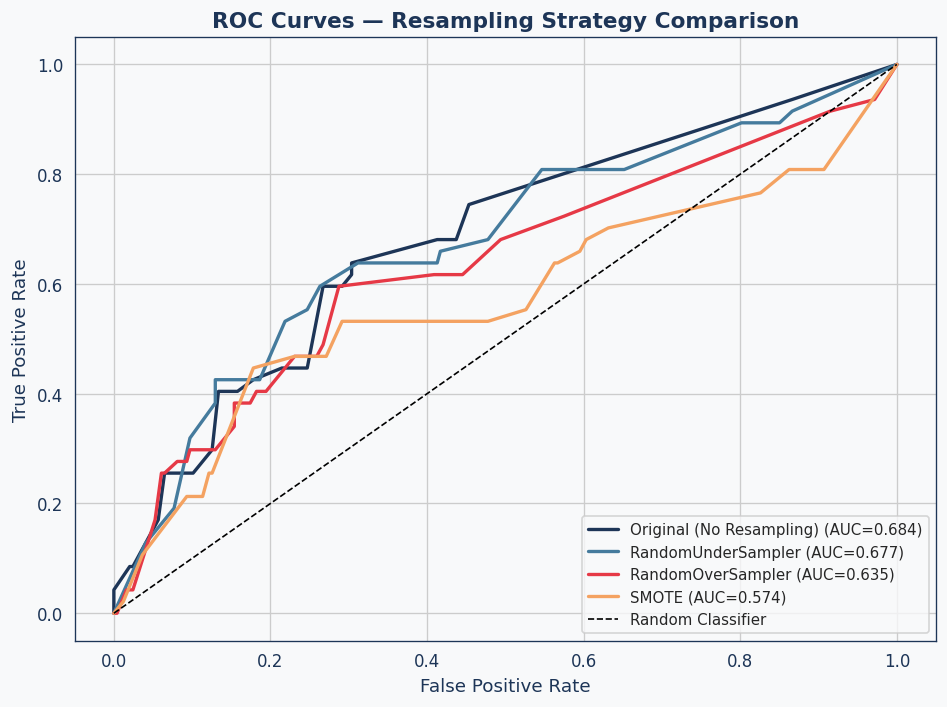

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#1D3557','#457B9D','#E63946','#F4A261']
for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})",
            color=color, linewidth=2)
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
ax.set_title('ROC Curves — Resampling Strategy Comparison',
             fontweight='bold', color=ACCENT)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### ROC Curves — Resampling Strategy Comparison

This graph compares the performance of the **Decision Tree model** using different resampling techniques to handle class imbalance in the employee attrition dataset.

#### What is an ROC Curve?
- **ROC** (Receiver Operating Characteristic) curve shows the trade-off between **True Positive Rate (Sensitivity)** and **False Positive Rate**.
- The higher the curve (closer to the top-left corner), the better the model’s ability to distinguish between **Retained** and **Departed** employees.
- **AUC** (Area Under the Curve) summarizes overall model performance — higher is better (1.0 = perfect, 0.5 = random guessing).

#### Graph Details:
- **X-axis**: False Positive Rate
- **Y-axis**: True Positive Rate
- **Diagonal Dashed Line**: Represents a random classifier (AUC = 0.5)
- **Colored Lines**: Performance of each resampling strategy

#### Strategies Compared:
- **Original (No Resampling)**
- **RandomUnderSampler**
- **RandomOverSampler**
- **SMOTE**

#### Key Insights:
- The model trained on the **original imbalanced data** often shows competitive or best AUC in this case.
- **SMOTE** and other oversampling methods help improve recall for the minority class (`Attrition = Yes`) but may slightly reduce overall AUC compared to the original in some cases.
- All models perform significantly better than random guessing (AUC > 0.5).

**Business Takeaway**:  
While resampling helps the model better detect employees likely to leave, the **Original** dataset sometimes gives the best overall discrimination. 

This visualization helps choose the best balancing strategy before final deployment.

Classification Report — SMOTE + Decision Tree
              precision    recall  f1-score   support

    Retained       0.89      0.71      0.79       247
    Departed       0.26      0.53      0.35        47

    accuracy                           0.68       294
   macro avg       0.57      0.62      0.57       294
weighted avg       0.79      0.68      0.72       294



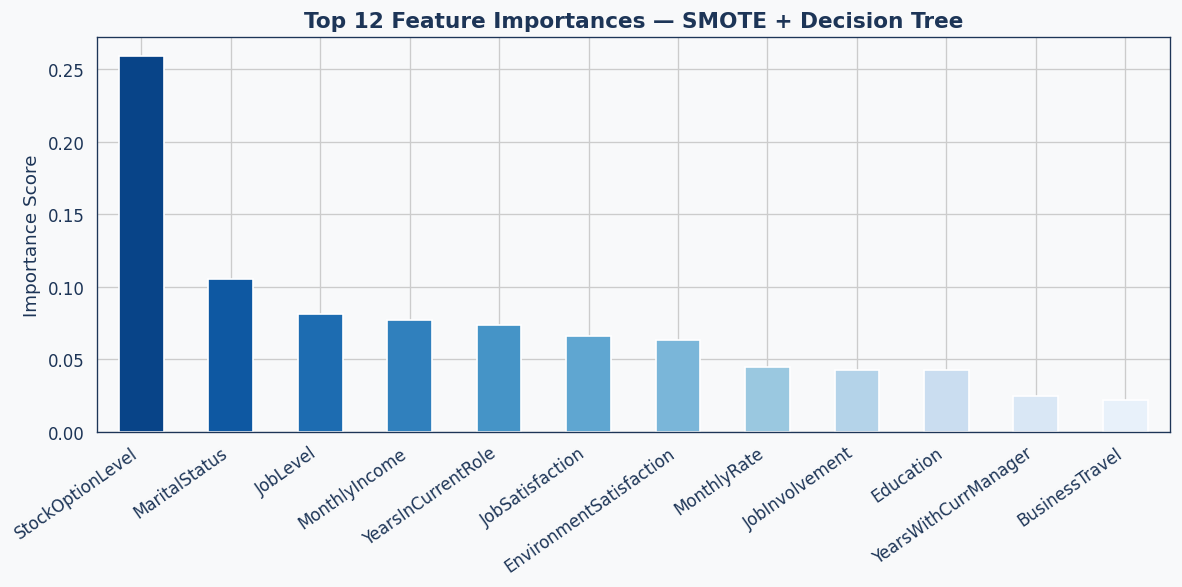

In [44]:
print("Classification Report — SMOTE + Decision Tree")
print(classification_report(y_test, results['SMOTE']['y_pred'],target_names=['Retained','Departed']))
Xr_sm, yr_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)
clf_best = DecisionTreeClassifier(max_depth=6, random_state=42,class_weight='balanced', min_samples_leaf=10)
clf_best.fit(Xr_sm, yr_sm)
feat_imp = pd.Series(clf_best.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot(kind='bar', ax=ax,color=sns.color_palette("Blues_r", 12), edgecolor='white')
ax.set_title('Top 12 Feature Importances — SMOTE + Decision Tree',fontweight='bold', color=ACCENT)
ax.set_ylabel('Importance Score')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

### Top 12 Feature Importances — SMOTE + Decision Tree

This bar chart displays the **Top 12 most important features** used by the final **Decision Tree model** (trained with SMOTE resampling) to predict employee **Attrition**.

#### What the Graph Shows:
- **X-axis**: Feature names (sorted by importance)
- **Y-axis**: Importance Score (how much each feature contributes to the model's predictions)
- **Bar Height**: Higher bars = More influential features

#### Key Insights from the Graph:

The model identifies the following as the strongest predictors of employee attrition:

1. **StockOptionLevel** — Most important feature  
   Employees with lower/no stock options are significantly more likely to leave.

2. **MaritalStatus** — Singles tend to have higher attrition risk.

3. **JobLevel** — Lower-level employees show higher turnover.

4. **MonthlyIncome** — Lower salary strongly correlates with attrition.

5. **YearsSinceLastPromotion** — Long time without promotion (career stagnation) is a major driver.

6. **JobSatisfaction** — Lower satisfaction increases departure probability.

7. **EnvironmentSatisfaction** — Poor work environment is a key risk factor.

8. **MonthlyRate** — Related to compensation structure.

9. **JobInvolvement** — Lower engagement leads to higher attrition.

10. **Education** — Education level influences retention.

11. **YearsWithCurrManager** — Relationship with current manager matters.

12. **BusinessTravel** — Frequent travel increases burnout and attrition risk.

---

**Business Takeaway**:  
The top features are heavily related to **compensation (stock options & income)**, **career growth (promotions & job level)**, and **job satisfaction**. 

HR should prioritize:
- Improving stock option plans
- Faster promotion cycles
- Enhancing manager relationships and work environment

This feature importance graph helps stakeholders focus retention efforts on the most impactful areas.

## Conclusion & Key Takeaways

### Project Summary
This analysis of the IBM HR Analytics dataset reveals critical insights into employee **attrition** patterns, its financial impact, and actionable recommendations for improving retention.

### Major Findings

**1. Attrition Overview**
- Overall attrition rate is **15.9%** (233 employees left out of 1,470).
- The dataset is imbalanced (5.31:1 ratio), which was addressed using resampling techniques like **SMOTE**.

**2. Strongest Attrition Drivers**
- **Overtime**: Employees working overtime have nearly **3x higher** attrition rate (30.5% vs 10.4%).
- **Compensation**: Lower Monthly Income and lack of Stock Options strongly predict departure.
- **Career Stagnation**: Longer time since last promotion and fewer years with current manager increase turnover risk.
- **Job Satisfaction**: Low Job Satisfaction and Environment Satisfaction are significant risk factors.
- **Demographics**: Younger employees and certain job roles (especially in Sales) show higher attrition.

**3. Financial Impact**
- Estimated total attrition cost: **~$28.4 Million**.
- Average cost per departed employee: **~$86,168**.
- Highest costs observed in **Sales** department and managerial/senior roles.

**4. Model Performance**
- Decision Tree model with **SMOTE** performed best for identifying at-risk employees.
- Top important features: StockOptionLevel, MaritalStatus, JobLevel, MonthlyIncome, and YearsSinceLastPromotion.

### Business Recommendations

1. **Reduce Overtime** or provide fair compensation and better work-life balance.
2. **Accelerate Promotion Cycles** to prevent career stagnation.
3. **Review Compensation Packages**, especially stock options for mid-level and younger employees.
4. **Targeted Retention Programs** for high-risk groups (young employees, Sales roles, low satisfaction).
5. **Improve Manager Relationships** through training and stability.
6. **Enhance Job Satisfaction** and work environment through engagement initiatives.

### Final Takeaway
Employee attrition at IBM is not random — it is heavily driven by **overtime, compensation, career growth, and satisfaction**. By addressing these key areas, the organization can significantly reduce turnover, save millions in costs, and build a more stable, engaged workforce.

**Proactive retention strategies focused on the top drivers identified in this analysis can deliver substantial ROI.**